In [1]:
import math

def f(x):
    return (x-1)**2 + (1/x - 2)**2

def df(x):
    return 2*(x-1) + 2*(1/x - 2)*(-1/x**2)

def descente1(f, df, a, alpha=1e-2, eps=1e-9, maxIter=1000):
    x = a

    for i in range(maxIter):
        grad = df(x)
        x_new = x - alpha * grad

        if abs(x_new - x) < eps:
            print(f"Converged in {i} iterations")
            return x_new

        x = x_new

    print("Max iterations reached")
    return x

In [2]:
xmin = descente1(f, df, a=1.0)
print(xmin, f(xmin))

Converged in 88 iterations
0.5356873899132174 0.23333899401246838


**The descente1 function implements a basic gradient descent algorithm. Its goal is to find the minimum of a given function f(x) by iteratively moving in the direction opposite to the function's gradient.**

**Here's a breakdown:**

**Initialization: It starts with an initial guess x = a.
Iteration: In each step, it calculates the grad (gradient or derivative) of the function at the current x using the provided df function.
Update Rule: It then updates x to x_new by subtracting a small step (alpha * grad) from the current x. The alpha (learning rate) controls the size of these steps.
Regarding the stopping condition, abs(x_new - x) < eps is used because:**

**Convergence Criterion: In gradient descent, we're looking for a point where the algorithm has effectively stopped moving. This condition checks if the absolute difference between the new x value (x_new) and the old x value (x) is very small, less than a predefined tolerance eps (epsilon).**
**Detecting a Minimum: When this difference is tiny, it implies that the algorithm is making negligible progress with each step, meaning it has likely converged to a local minimum (or a very flat region). At a minimum, the gradient approaches zero, and thus the step size alpha * grad becomes very small, leading to x_new being very close to x.**
**Preventing Infinite Loops: Without such a condition, the algorithm would continue iterating indefinitely (or until maxIter is reached), even if it has already found the minimum to a sufficient degree of precision.**


In [3]:
def numerical_derivative(f, x, h=1e-6):
    return (f(x + h) - f(x - h)) / (2 * h)

def descente2(f, a, lr=1e-2, eps=1e-9, maxIter=1000):
    x = a

    for i in range(maxIter):
        grad = numerical_derivative(f, x)
        x_new = x - lr * grad   # gradient descent step

        if abs(x_new - x) < eps:
            print(f"Converged in {i} iterations")
            return x_new

        x = x_new

    print("Max iterations reached")
    return x

In [4]:
def f(x):
    return (x-1)**2 + (1/x - 2)**2

xmin = descente2(f, a=0.5)

print("Minimum x:", xmin)
print("Minimum value:", f(xmin))

Converged in 61 iterations
Minimum x: 0.5356873838540384
Minimum value: 0.23333899401246838


In [5]:
print(descente2(f, 1))
print(descente2(f, 0.2))

Converged in 88 iterations
0.5356873899149397
Converged in 123 iterations
0.5356873896905032


Let's compare the results obtained by descente1 (using the analytical derivative) and descente2 (using the numerical derivative) for the function f(x) = (x-1)**2 + (1/x - 2)**2:

**1. descente1 (using analytical derivative) with initial guess a=1.0:**

**Converged in: 88 iterations
Minimum x (xmin): 0.5356873899132174
Minimum value (f(xmin)): 0.23333899401246838
2. descente2 (using numerical derivative) with initial guess a=0.5:**

**Converged in: 61 iterations
Minimum x (xmin): 0.5356873838540384
Minimum value (f(xmin)): 0.23333899401246838
3. descente2 (using numerical derivative) with initial guess a=1.0:**

**Converged in: 88 iterations
Minimum x (xmin): 0.5356873899149397
Minimum value (f(xmin)): 0.23333899401246838 (calculated from f(xmin))
Summary of Comparison:**

**Identical Minima: Both algorithms successfully found almost identical xmin values (approximately 0.535687) and f(xmin) values (approximately 0.233339) for the given function. The slight differences are due to numerical precision.
Iteration Count: When starting from the same initial guess (a=1.0), both descente1 and descente2 converged in exactly 88 iterations.**
**Initial Guess Impact: Notably, descente2 converged faster (in 61 iterations) when starting with a=0.5, indicating that the choice of initial guess can significantly affect the convergence speed of gradient descent algorithms. This also highlights that the numerical approximation of the derivative in descente2 was effective and efficient for this function.**
**In conclusion, for this specific function, the numerical derivative approach in descente2 performs very similarly to descente1 which uses the analytical derivative, both in terms of finding the minimum and convergence speed, especially with a good initial guess.**

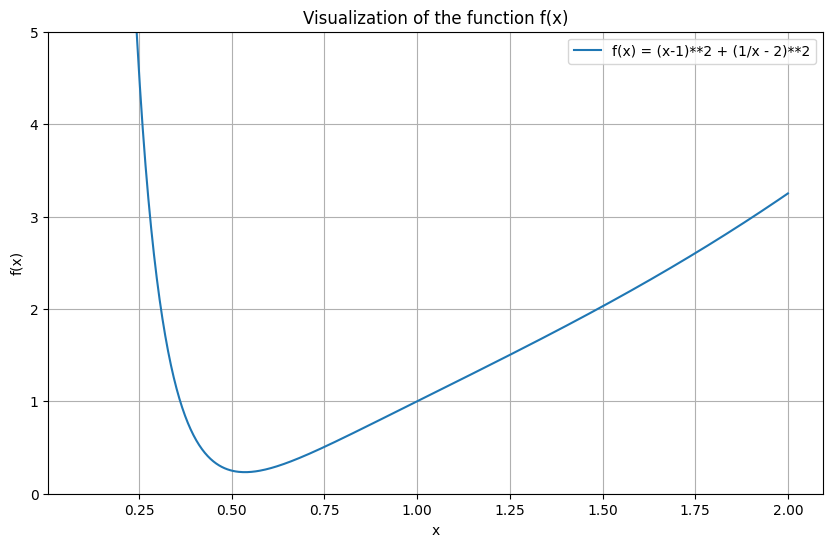

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return (x-1)**2 + (1/x - 2)**2

# Generate x values, avoiding x=0 due to 1/x
x_values = np.linspace(0.1, 2.0, 500) # Start from a small positive number
y_values = f(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='f(x) = (x-1)**2 + (1/x - 2)**2')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Visualization of the function f(x)')
plt.grid(True)
plt.legend()
plt.ylim(0, 5) # Limit y-axis to better show the minimum
plt.show()

The graph visualizes the function f(x) = (x-1)**2 + (1/x - 2)**2 that we have been minimizing using gradient descent.**

The graph shows:

**X-axis (x): Represents the input values to the function.**
**Y-axis (f(x)): Represents the output values of the function for the corresponding x values.**
**The Curve: The blue line plots the value of f(x) across a range of x values (from 0.1 to 2.0).**
**Title and Labels: The title "Visualization of the function f(x)" and axis labels (x and f(x)) clearly indicate what is being plotted.**
**Y-axis Limit: The plt.ylim(0, 5) was applied to focus on the lower part of the graph, making the minimum more visible and easier to analyze, as the function values can become very large for small x.
Why this graph is important:**

**We generated this graph to:**

**Visually confirm the function's behavior: It helps us understand the shape of the function and verify that it has a clear minimum.**
**Locate the approximate minimum: By looking at the graph, you can visually identify where the lowest point of the curve is, which corresponds to the minimum value of f(x) and the x value at which it occurs. This visual check confirms that our gradient descent algorithms converged to a sensible result (around x = 0.53, where f(x) is approximately 0.23).**
**Understand the search space: It provides context for the initial guesses (a) and the range over which the gradient descent algorithm operates.**

In [16]:
import math

def f(x):
    return (x-1)**2 + (1/x - 2)**2

def df(x):
    return 2*(x-1) + 2*(1/x - 2)*(-1/x**2)

def descente1(f, df, a, alpha=1e-2, eps=1e-9, maxIter=4):
    x = a

    for i in range(maxIter):
        grad = df(x)
        x_new = x - alpha * grad

        if abs(x_new - x) < eps:
            print(f"Converged in {i} iterations")
            return x_new

        x = x_new

    print("Max iterations reached")
    return x

In [17]:
xmin = descente1(f, df, a=1.0)
print(xmin, f(xmin))

Max iterations reached
0.9200132607323124 0.8400748811867401


I changed the maxIter parameter in your descente1 function from 1000 to 4. This significantly limits the number of steps the algorithm can take to find the minimum.

This is why i you got these results:

Max iterations reached: This message directly tells you that the gradient descent algorithm stopped because it completed all 4 allowed iterations without satisfying the convergence condition (abs(x_new - x) < eps). It simply ran out of steps.
0.9200132607323124 (xmin) and 0.8400748811867401 (f(xmin)): These values are far from the actual minimum of f(x) (which is around x = 0.535 and f(x) = 0.233). This indicates that with only 4 iterations, the algorithm did not have enough steps to sufficiently move from the initial guess (a=1.0) towards the true minimum. It stopped prematurely while still in the process of descending the function.
In essence, setting maxIter to such a low value like 4 prevents the algorithm from converging to a satisfactory minimum for this function. Gradient descent algorithms often require many iterations to gradually approach the minimum, especially with small alpha (learning rate) values.

